In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

# 1. Mount Google Drive (if your data is there)
# from google.colab import drive
# drive.mount('/content/drive')

# Define path and parameters
data_dir = '/content/drive/MyDrive/kidney-ct-scan-image'  # Update this to your path
batch_size = 32
img_size = (224, 224)

# Load training and validation sets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 465 files belonging to 2 classes.
Using 372 files for training.
Found 465 files belonging to 2 classes.
Using 93 files for validation.


In [2]:
# Configure for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Data Augmentation (helps prevent overfitting)
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
])

# Load pre-trained model
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3),
                                               include_top=False,
                                               weights='imagenet')
base_model.trainable = False  # Freeze the base

# Final Architecture
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1./127.5, offset=-1), # Normalize pixels to [-1, 1]
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 56s 4s/step - accuracy: 0.7715 - loss: 0.4956 - val_accuracy: 0.8172 - val_loss: 0.4297
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.8925 - loss: 0.2943 - val_accuracy: 0.8925 - val_loss: 0.3182
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9167 - loss: 0.2076 - val_accuracy: 0.9140 - val_loss: 0.2766
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.9489 - loss: 0.1812 - val_accuracy: 0.9355 - val_loss: 0.2197
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9651 - loss: 0.1386 - val_accuracy: 0.9247 - val_loss: 0.2271
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.9624 - loss: 0.1176 - val_accuracy: 0.9892 - val_loss: 0.1742
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9839 - loss: 0.1057 - val_accuracy: 0.9462 - val_loss: 0.1922
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9785 - loss: 0.0943 - val_accuracy: 0.9462 - val_loss:

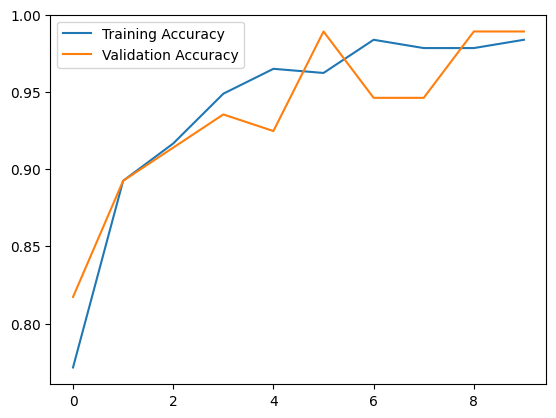

In [3]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# Plot Results
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend()
plt.show()

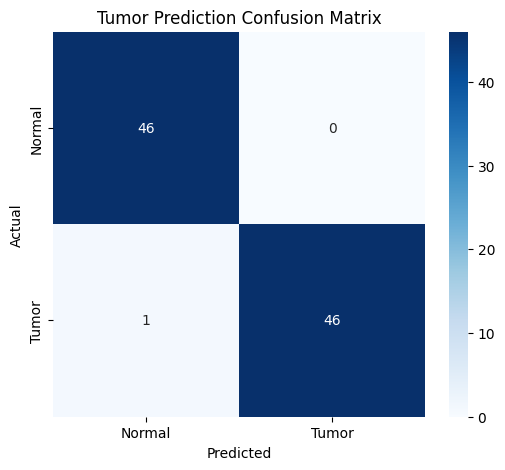

              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99        46
       Tumor       1.00      0.98      0.99        47

    accuracy                           0.99        93
   macro avg       0.99      0.99      0.99        93
weighted avg       0.99      0.99      0.99        93



In [4]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Get all labels and predictions from the validation set
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype(int).flatten())

# 2. Create Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Tumor'],
            yticklabels=['Normal', 'Tumor'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Tumor Prediction Confusion Matrix')
plt.show()

# 3. Print Precision, Recall, and F1-Score
print(classification_report(y_true, y_pred, target_names=['Normal', 'Tumor']))

In [5]:
def predict_tumor(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) # Create a batch

    prediction = model.predict(img_array)
    score = prediction[0][0]

    # Using 0.5 as the threshold
    result = "Tumor" if score > 0.5 else "Normal"
    confidence = score if score > 0.5 else 1 - score

    print(f"Result: {result} ({confidence*100:.2f}% confidence)")

# Example usage:
#   predict_tumor('/content/dataset/test_image.jpg')

In [7]:
predict_tumor('/content/drive/MyDrive/kidney-ct-scan-image/Tumor/Tumor- (702).jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Result: Tumor (93.25% confidence)


In [8]:
# Save the entire model (architecture + weights)
model.save('tumor_model.keras')

# Download it to your computer
from google.colab import files
files.download('tumor_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# In Google Colab
model.save_weights('tumor_weights.weights.h5')
from google.colab import files
files.download('tumor_weights.weights.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>